In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
"""Summary
- This cell builds a 2D nx-by-ny square lattice tight-binding model with open boundary conditions,
  assembles a mean-field Bogoliubov-de Gennes (BdG) Hamiltonian with an onsite s-wave pairing Δ (here initialized to ones),
  diagonalizes it and prints the BdG eigenvalues.

Step-by-step
- Grid and parameters: nx, ny → N = nx*ny sites; t (hopping), mu (chemical potential), k_B = Boltzmann constant.
- diff(): small helper to compute array difference used for neighbor selection.
- NN array: stores neighbors (stored as 1-based indices, zeros mean “no neighbor”).
- Nearest-neighbor assignment: fills NN with right/left/up/down neighbors (open BCs).
- H: N*N tight-binding Hamiltonian, off-diagonals = -t for nearest neighbors, diagonal = 4*t - mu (onsite term).
- BdG assembly: builds 4N*4N BdG Hamiltonian in the basis (c_up, c_dn, c_up^†, c_dn^†) using arr_delta = ones(N) and blocks H_1, H_Delta.
- Diagonalization: prints eigenvalues of the Hermitian BdG matrix (quasiparticle energies). Expect particle-hole symmetry (±E pairs) in the spectrum.
"""
nx = 6      # sites on x axis
ny = 6      # sites on y axis

N = nx*ny # total number of sites

t = 1      # hopping constant
mu = 4*t   # chemical potential
Delta = 1  # superconducting gap

k_B = 1    # Boltzmann constant
U_0 = 3*t  # interaction strength
ite = 1600   # number of iterations
######################################################################
# Helper function to generate nearest neighbor list with open boundary conditions
def generate_nn_list_obc(nx, ny):  # open boundary condition
    N = nx * ny
    NN = np.zeros((N, 5), dtype=int)  # [self, right, left, up, down]
    for i in range(N):
        x = i % nx
        y = i // nx
        self_idx = i + 1

        # Right neighbour (if not at right edge)
        if x < nx - 1:
            right = i + 2
        else:
            right = 0

        # Left neighbour (if not at left edge)
        if x > 0:
            left = i
        else:
            left = 0

        # Up neighbour (if not at top edge)
        if y > 0:
            up = i - nx + 1
        else:
            up = 0

        # Down neighbour (if not at bottom edge)
        if y < ny - 1:
            down = i + nx + 1
        else:
            down = 0

        NN[i] = [self_idx, right, left, up, down]
    return NN

##############################################################
H = np.zeros([N, N])                       # Hamiltonian
NN = generate_nn_list_obc(nx, ny)          # nearest neighbor list
for i in NN:                               # connecting NN List to Hamiltonian
    if i[1] != 0:
        H[int(i[0] -1)][int(i[1]-1)] =  -t             #connecting +x 

    if i[2] != 0:
        H[int(i[0] -1)][int(i[2]-1)] =  -t            #connecting -x

    if i[3] != 0:
        H[int(i[0]-1)][int(i[3]-1)]  =   -t                  #connecting +y

    if i[4] != 0:
        H[int(i[0] -1)][int(i[4]-1)] =  -t                  #connecting -y
  
for i in np.arange(N):
    H[i,i] = 4*t - mu
    
arr_delta = Delta*np.ones(N)
H_Delta_corner = np.diag(arr_delta)
H_1 = np.block([[H, np.zeros([N,N])], [np.transpose(np.conj(np.zeros([N,N]))), H]])                ## spin sector
H_Delta = np.block([[np.zeros([N, N]), H_Delta_corner], [-H_Delta_corner, np.zeros([N,N])]])      # Delta block 2N by 2N
#Building bogoliubov-de-Gennes hamiltonian:
H_BdG = np.block([[H_1, H_Delta], [np.transpose(np.conj(H_Delta)), -np.conj(H_1)]])
    
print(np.linalg.eigvalsh(H_BdG))

[-3.74004257 -3.74004257 -3.74004257 -3.74004257 -3.20872201 -3.20872201
 -3.20872201 -3.20872201 -3.20872201 -3.20872201 -3.20872201 -3.20872201
 -2.68697461 -2.68697461 -2.68697461 -2.68697461 -2.45945468 -2.45945468
 -2.45945468 -2.45945468 -2.45945468 -2.45945468 -2.45945468 -2.45945468
 -1.96543549 -1.96543549 -1.96543549 -1.96543549 -1.96543549 -1.96543549
 -1.96543549 -1.96543549 -1.68557598 -1.68557598 -1.68557598 -1.68557598
 -1.68557598 -1.68557598 -1.68557598 -1.68557598 -1.33874906 -1.33874906
 -1.33874906 -1.33874906 -1.28183623 -1.28183623 -1.28183623 -1.28183623
 -1.28183623 -1.28183623 -1.28183623 -1.28183623 -1.14366889 -1.14366889
 -1.14366889 -1.14366889 -1.14366889 -1.14366889 -1.14366889 -1.14366889
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
  1.          1.          1.          1.          1.          1.
  1.          1.          1.          1.          1.          1.
  1.143668

In [3]:
def update_delta(E, W, U_site, T):
    """
    Compute onsite singlet Δ_i in vectorized form.

    Basis: (c_up_1..N, c_dn_1..N, c_up^†_1..N, c_dn^†_1..N)

    Parameters
    ----------
    E : (4N,) eigenvalues
    W : (4N, 4N) eigenvectors (columns are eigenstates)
    U_site : (N,) onsite attraction values
    T : temperature in Kelvin
    """
    N = U_site.shape[0]
    # Blocks (N x M)
    u_up = W[0:N,     :]    # (N, M)
    u_dn = W[N:2*N,   :]    # (N, M)
    v_up = W[2*N:3*N, :]    # (N, M)
    v_dn = W[3*N:4*N, :]    # (N, M)

    # Fermi function
    fermi = 0.5 * (1.0 - np.tanh(E / (2.0 *k_B * T)))  # shape (M,)

    # Terms (N x M)
    term1 = u_dn * np.conjugate(v_up) * (1.0 - fermi)[None, :]
    term2 = np.conjugate(v_dn) * u_up * fermi[None, :]

    F = np.sum(term1 + term2, axis=1)   # (N,)
    Delta_new = -U_site * F
    
    return Delta_new


Delta converged on 2.551290876598661 at iteration 10 for T = 0.0001.
Delta converged on 2.551290876598661 at iteration 10 for T = 0.0203010101010101.
Delta converged on 2.551290876598661 at iteration 10 for T = 0.040502020202020206.
Delta converged on 2.5512908765984204 at iteration 10 for T = 0.06070303030303031.
Delta converged on 2.5512908765830797 at iteration 10 for T = 0.08090404040404041.
Delta converged on 2.5512908763782196 at iteration 10 for T = 0.10110505050505052.
Delta converged on 2.5512908737049695 at iteration 10 for T = 0.12130606060606061.
Delta converged on 2.5512908347298953 at iteration 10 for T = 0.1415070707070707.
Delta converged on 2.5512904907157146 at iteration 10 for T = 0.1617080808080808.
Delta converged on 2.5512886120126343 at iteration 10 for T = 0.1819090909090909.
Delta converged on 2.5512814313300125 at iteration 10 for T = 0.20211010101010102.
Delta converged on 2.551260310951676 at iteration 10 for T = 0.2223111111111111.
Delta converged on 2.5512

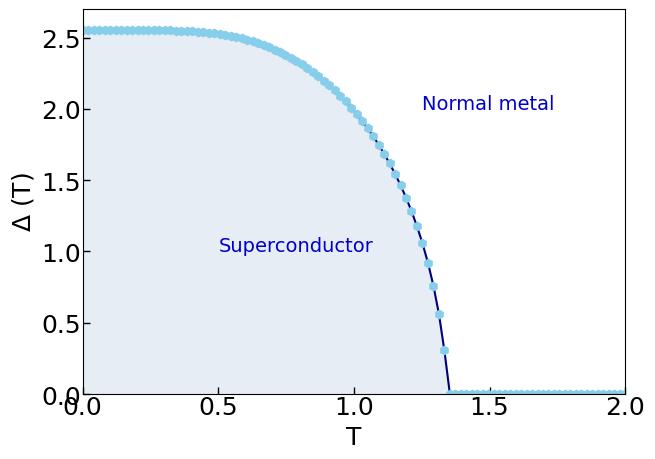

In [4]:
def delta_vs_Temp(Temp):
    # Self consistent loop
    for k in np.arange(ite):
        if k ==0:        
            arr_delta = Delta*np.ones(N)           


        elif 0 < k < ite-1:  
            new_delta_mean = np.mean(arr_delta)
            if np.abs(new_delta_mean - old_delta_mean) < 1e-5:  # convergence condition           
                print(f"Delta converged on {new_delta_mean} at iteration {k} for T = {Temp}.")
                return np.mean(arr_delta)              # returning converged mean delta after final iteration.
        
        else:
            pass
        
        old_delta_mean = np.mean(arr_delta)

        H_Delta_corner = np.diag(arr_delta)
        H_1 = np.block([[H, np.zeros([N,N])], [np.transpose(np.conj(np.zeros([N,N]))), H]])       ## spin sector
        H_Delta = np.block([[np.zeros([N, N]), H_Delta_corner], [-H_Delta_corner, np.zeros([N,N])]])      # Delta block 2N by 2N
        #Building bogoliubov-de-Gennes hamiltonian:
        H_BdG = np.block([[H_1, H_Delta], [np.transpose(np.conj(H_Delta)), -np.conj(H_1)]])
    
        # self consistent delta in making
        egnvl_, egvec_ = np.linalg.eigh(H_BdG)   # diagonalizing
        ##########################################################################################################################
        ############### updating delta in vectorized form
        arr_delta = update_delta(egnvl_, egvec_, U_0*np.ones(N), Temp)
            
        
##################################################################################################################

if __name__ == "__main__":
    ############# calculating delta vs temperature
    Delta_T = []                   # list to store delta vs temperature
    temp = np.linspace(0.0001, 2.0, 100)  # temperature range

    for k in temp:                      # loop over temperature
        Delta_T.append(delta_vs_Temp(k))
    ######################################################################


    #######plotting####################
    fig, ax1 = plt.subplots(1, sharex = True, figsize = [7,5] )#), hspace = 0)
    plt.subplots_adjust(wspace=0 , hspace=0)

    ax1.plot(temp, Delta_T, "-", color = "navy")
    ax1.fill_between(temp, Delta_T, color="lightsteelblue", alpha=0.3, zorder=0)
    ax1.plot(temp, Delta_T, "h", color = "skyblue")
    ax1.set_ylabel(r"$\Delta$ (T)", fontsize = 18)
    ax1.set_xlabel(r"T", fontsize = 18)
    ax1.set_xlim([0,2])
    ax1.set_ylim([0,2.7])
    ax1.tick_params(labelsize=18, direction = "in", length = 5, pad  = 1, width = 1 )

    ################################################################################
    font_dict = {
        'family': 'sans-serif',   # Font family
        'color': 'mediumblue',    # Font color
        'weight': 'light',    # Font weight
        'style': 'normal',   # Font style
        'size': 14           # Font size
    }

    # Define the text properties
    text = r"Superconductor"
    text1 = r"Normal metal"
    textbox_props = dict(boxstyle='square', facecolor='grey', alpha=0)
    # Add the textbox
    ax1.text(0.5, 1, text, fontdict=font_dict, bbox=textbox_props)
    # Add the textbox
    ax1.text(1.25, 2, text1, fontdict=font_dict, bbox=textbox_props)
    plt.savefig("Delta_vs_T_BCS_s_wave_superconductor_calculated_self_consistently.pdf", bbox_inches = "tight")